In [1]:
try:
    import xgboost
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost'])


# AQI Forecasting — XGBoost Model
**Dataset:** Kodungaiyur_AQI_data.csv  
**Target:** Daily mean AQI  
**Model:** XGBoost with lag features + calendar features + pollutant sub-indices

XGBoost is a gradient-boosted tree ensemble. It cannot natively handle time-series ordering,
so we engineer meaningful features: lagged AQI values, rolling statistics, day-of-week, month, and pollutant levels.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully.')
print(f'XGBoost version: {xgb.__version__}')

Libraries loaded successfully.
XGBoost version: 2.1.3


## 1. Load & Preprocess Data

In [3]:
df = pd.read_csv('D:/AQI_Project/Data/Final/Kodungaiyur_AQI_daily_clean.csv', parse_dates=['Timestamp'])
df = df.set_index('Timestamp').sort_index()

df = df.drop(columns=['AQI_Category'], errors='ignore')   # ← ADD THIS LINE

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce').interpolate(method='time')

daily = df.resample('D').mean().dropna(subset=['AQI'])
print(f'Daily records: {len(daily)}')
print(daily.head())

Daily records: 1826
                 PM25       PM10        NO2        SO2       NH3         CO  \
Timestamp                                                                     
2021-01-01  82.674286  90.887143  10.374286   8.245714  4.757143  22.842105   
2021-01-02  80.876667  85.314167  11.400000  10.165833  5.023750  26.681250   
2021-01-03  74.210000  72.862917  13.541250  14.491250  5.118333  22.748750   
2021-01-04  52.204762  62.708750  11.829167  10.733750  5.139167  21.847083   
2021-01-05  39.020909  50.272609  14.248333   9.897083  5.050000  29.404583   

                   O3        AQI  
Timestamp                         
2021-01-01  22.963158  48.865789  
2021-01-02  20.987917  85.609167  
2021-01-03  28.029167  74.642917  
2021-01-04  22.238750  62.708750  
2021-01-05  23.756667  50.482917  


## 2. Feature Engineering

In [4]:
def create_features(df_in):
    df_f = df_in.copy()

    # Lag features (past AQI values)
    for lag in [1, 2, 3, 4, 5, 6, 7, 9, 14, 30]:
        df_f[f'lag_{lag}'] = df_f['AQI'].shift(lag)

    # Rolling statistics
    df_f['roll_mean_7']  = df_f['AQI'].shift(1).rolling(7).mean()
    df_f['roll_std_7']   = df_f['AQI'].shift(1).rolling(7).std()
    df_f['roll_mean_30'] = df_f['AQI'].shift(1).rolling(30).mean()

    # Calendar features
    df_f['day_of_week'] = df_f.index.dayofweek
    df_f['month']       = df_f.index.month
    df_f['day_of_year'] = df_f.index.dayofyear
    df_f['quarter']     = df_f.index.quarter

    # Cyclical encoding for seasonality
    df_f['month_sin'] = np.sin(2 * np.pi * df_f['month'] / 12)
    df_f['month_cos'] = np.cos(2 * np.pi * df_f['month'] / 12)
    df_f['dow_sin']   = np.sin(2 * np.pi * df_f['day_of_week'] / 7)
    df_f['dow_cos']   = np.cos(2 * np.pi * df_f['day_of_week'] / 7)

    return df_f


featured = create_features(daily)
featured = featured.dropna()  # drop rows with NaN from lag creation

feature_cols = [c for c in featured.columns if c != 'AQI' and c != 'AQI_Category']
print(f'Feature count: {len(feature_cols)}')
print('Features:', feature_cols)

Feature count: 28
Features: ['PM25', 'PM10', 'NO2', 'SO2', 'NH3', 'CO', 'O3', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'lag_9', 'lag_14', 'lag_30', 'roll_mean_7', 'roll_std_7', 'roll_mean_30', 'day_of_week', 'month', 'day_of_year', 'quarter', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos']


## 3. Train/Test Split (Temporal)

In [5]:
split_date = '2025-07-01'
train = featured[:split_date]
test  = featured[split_date:]

X_train = train[feature_cols]
y_train = train['AQI']
X_test  = test[feature_cols]
y_test  = test['AQI']

print(f'Train: {len(train)} | Test: {len(test)}')

Train: 1613 | Test: 184


## 4. Train XGBoost Model

In [6]:
model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=30,
    eval_metric='rmse'
)

# Time-based validation split from train
val_split = int(len(X_train) * 0.85)
X_tr, X_val = X_train.iloc[:val_split], X_train.iloc[val_split:]
y_tr, y_val = y_train.iloc[:val_split], y_train.iloc[val_split:]

model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=50
)
print(f'Best iteration: {model.best_iteration}')

[0]	validation_0-rmse:26.68035
[50]	validation_0-rmse:9.63302
[100]	validation_0-rmse:5.80811
[150]	validation_0-rmse:4.84812
[200]	validation_0-rmse:4.42511
[250]	validation_0-rmse:4.11301
[300]	validation_0-rmse:3.95504
[350]	validation_0-rmse:3.83389
[400]	validation_0-rmse:3.77176
[450]	validation_0-rmse:3.72074
[499]	validation_0-rmse:3.69010
Best iteration: 498


## 5. Forecast & Evaluation

Note: Features that use lagged AQI will use *actual* test values for a fair direct evaluation.
For truly recursive forecasting, see the cell below.

In [7]:
# Direct forecast (uses actual test-period lag values)
pred_direct = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred_direct))
mae  = mean_absolute_error(y_test, pred_direct)
mask = y_test.values != 0
mape = np.mean(np.abs((y_test.values[mask] - pred_direct[mask]) / y_test.values[mask])) * 100

print(f'XGBoost Direct Forecast:')
print(f'  RMSE : {rmse:.2f}')
print(f'  MAE  : {mae:.2f}')
print(f'  MAPE : {mape:.2f}%')

XGBoost Direct Forecast:
  RMSE : 22.53
  MAE  : 8.56
  MAPE : 7.43%


In [8]:
# Recursive (multi-step ahead) forecast — uses predicted values as lag inputs
def recursive_forecast(model, train_df, test_df, feature_cols, lag_cols):
    all_data = pd.concat([train_df, test_df])
    all_data = all_data.copy()
    predictions = []

    for i in range(len(train_df), len(all_data)):
        row = all_data.iloc[i]
        feat = row[feature_cols].values.reshape(1, -1)
        pred = model.predict(feat)[0]
        predictions.append(pred)
        # Update lag columns in subsequent rows
        if i + 1 < len(all_data):
            for lag_col in lag_cols:
                lag_n = int(lag_col.split('_')[1])
                if len(predictions) >= lag_n:
                    all_data.at[all_data.index[i+1], lag_col] = predictions[-lag_n]

    return np.array(predictions)

lag_cols = [c for c in feature_cols if c.startswith('lag_')]
pred_recursive = recursive_forecast(model, train, test, feature_cols, lag_cols)

rmse_r = np.sqrt(mean_squared_error(y_test, pred_recursive))
mae_r  = mean_absolute_error(y_test, pred_recursive)
print(f'XGBoost Recursive Forecast: RMSE={rmse_r:.2f}  MAE={mae_r:.2f}')

XGBoost Recursive Forecast: RMSE=22.70  MAE=8.75


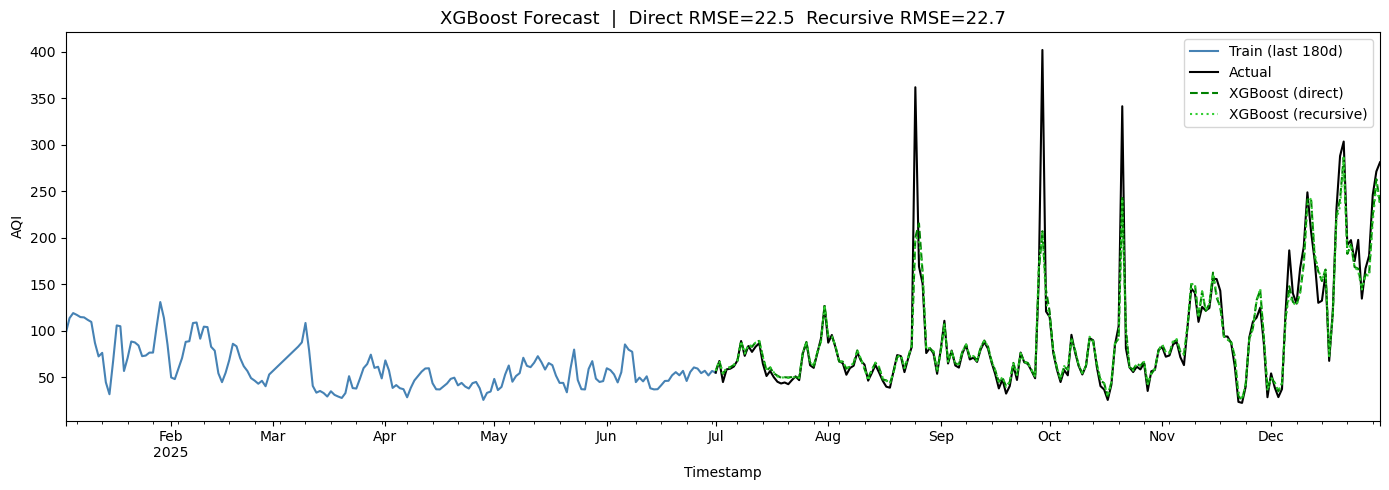

In [9]:
fig, ax = plt.subplots(figsize=(14, 5))
y_train[-180:].plot(ax=ax, label='Train (last 180d)', color='steelblue')
y_test.plot(ax=ax, label='Actual', color='black', linewidth=1.5)
ax.plot(y_test.index, pred_direct, label='XGBoost (direct)', color='green', linestyle='--')
ax.plot(y_test.index, pred_recursive, label='XGBoost (recursive)', color='limegreen', linestyle=':')
ax.set_title(f'XGBoost Forecast  |  Direct RMSE={rmse:.1f}  Recursive RMSE={rmse_r:.1f}', fontsize=13)
ax.set_ylabel('AQI')
ax.legend()
plt.tight_layout()
import os
os.makedirs('images', exist_ok=True)
plt.savefig('images/xgboost_forecast_kodangaiyur.png', dpi=150)
plt.show()

## 6. Feature Importance

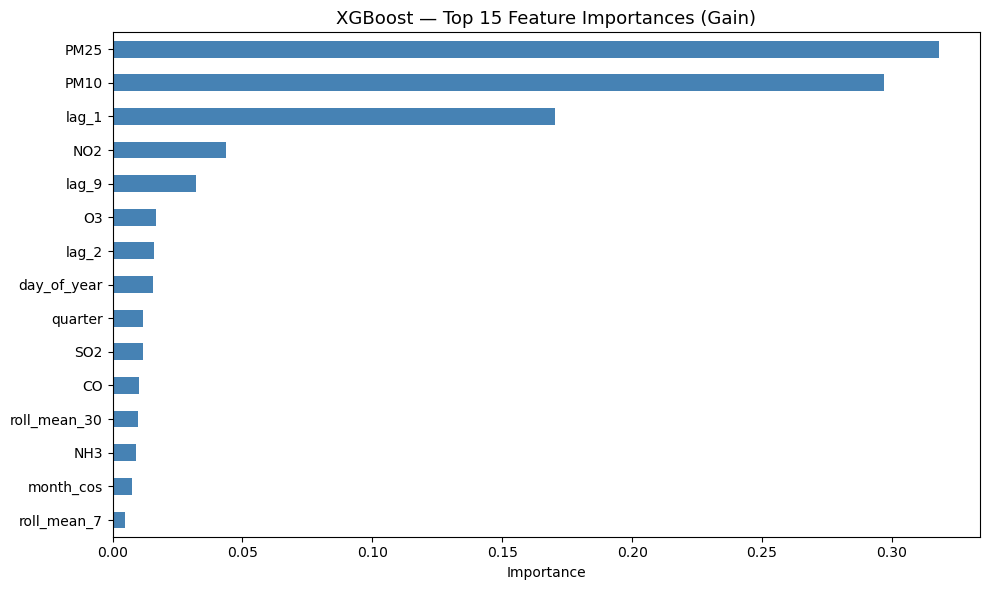

PM25           0.317986
PM10           0.296854
lag_1          0.170186
NO2            0.043596
lag_9          0.032249
O3             0.016793
lag_2          0.016056
day_of_year    0.015464
quarter        0.011798
SO2            0.011692
dtype: float32


In [10]:
plt.close('all')
importance = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
importance.head(15).plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_title('XGBoost — Top 15 Feature Importances (Gain)', fontsize=13)
ax.set_xlabel('Importance')
plt.tight_layout()
import os
os.makedirs('images', exist_ok=True)
plt.savefig('images/xgboost_feature_importance_kodangaiyur.png', dpi=100)
plt.show()
print(importance.head(10))

## 7. Learning Curve

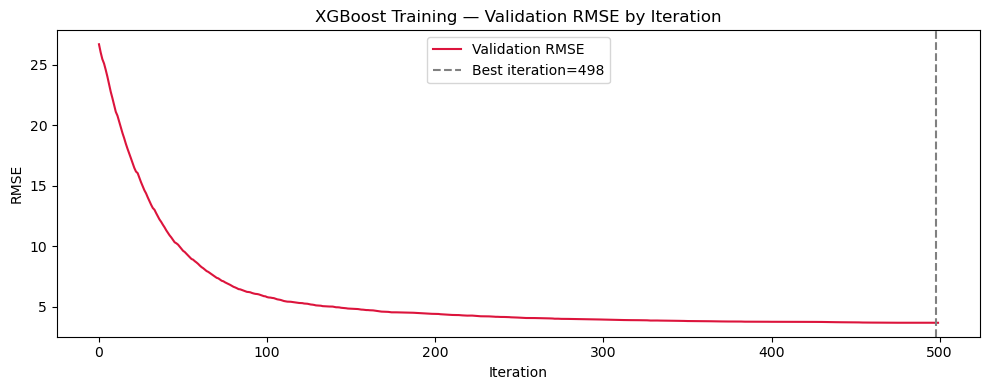

In [11]:
evals_result = model.evals_result()
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(evals_result['validation_0']['rmse'], label='Validation RMSE', color='crimson')
ax.axvline(model.best_iteration, linestyle='--', color='gray', label=f'Best iteration={model.best_iteration}')
ax.set_title('XGBoost Training — Validation RMSE by Iteration')
ax.set_xlabel('Iteration')
ax.set_ylabel('RMSE')
ax.legend()
plt.tight_layout()
import os
os.makedirs('images', exist_ok=True)
plt.savefig('images/xgboost_learning_curve_kodangaiyur.png', dpi=150)
plt.show()

## 8. Classification Metrics & Confusion Matrix
Converting continuous AQI forecasts into discrete AQI categories to evaluate classification performance (Accuracy, Precision, Recall).

Classification Metrics for AQI Categories:
Accuracy:  0.9293
Precision: 0.9156 (Weighted)
Recall:    0.9293 (Weighted)

Classification Report:
              precision    recall  f1-score   support

        Good       0.92      0.80      0.86        30
Satisfactory       0.94      0.98      0.96       104
    Moderate       1.00      0.97      0.99        39
        Poor       0.64      1.00      0.78         7
   Very Poor       0.00      0.00      0.00         3
      Severe       0.00      0.00      0.00         1

    accuracy                           0.93       184
   macro avg       0.58      0.63      0.60       184
weighted avg       0.92      0.93      0.92       184



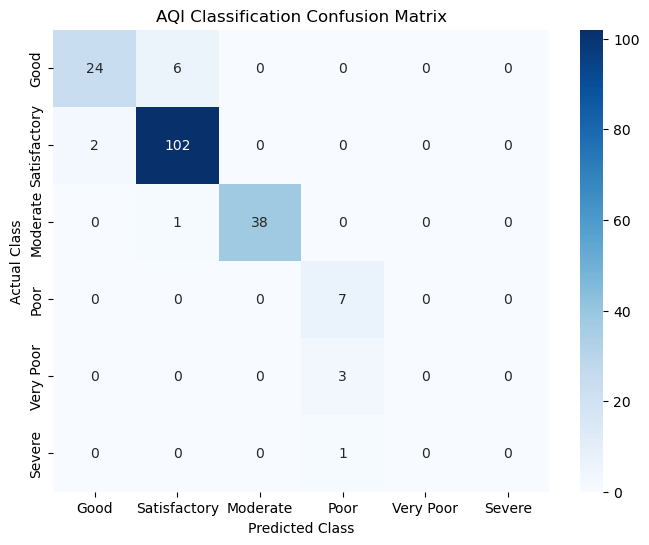

In [12]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

# Define AQI categories based on Indian standards
def categorize_aqi(aqi_values):
    categories = []
    for val in aqi_values:
        if val <= 50:
            categories.append('Good')
        elif val <= 100:
            categories.append('Satisfactory')
        elif val <= 200:
            categories.append('Moderate')
        elif val <= 300:
            categories.append('Poor')
        elif val <= 400:
            categories.append('Very Poor')
        else:
            categories.append('Severe')
    return np.array(categories)

# Ensure values are flattened arrays
y_true_cont = np.array(y_test.values).flatten()
y_pred_cont = np.array(pred_recursive).flatten()

# Convert continuous predictions to discrete AQI classes
y_true_class = categorize_aqi(y_true_cont)
y_pred_class = categorize_aqi(y_pred_cont)

# Labels for standard Indian AQI
labels = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
# Filter labels to only those present in the actual or predicted to avoid empty rows/cols if desired
# But keeping all labels shows a full matrix
present_labels = [l for l in labels if l in y_true_class or l in y_pred_class]

# Calculate Metrics
acc = accuracy_score(y_true_class, y_pred_class)
# weighted average for precision and recall since it's multiclass
prec = precision_score(y_true_class, y_pred_class, average='weighted', zero_division=0)
rec = recall_score(y_true_class, y_pred_class, average='weighted', zero_division=0)

print(f"Classification Metrics for AQI Categories:")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f} (Weighted)")
print(f"Recall:    {rec:.4f} (Weighted)\n")

print("Classification Report:")
print(classification_report(y_true_class, y_pred_class, labels=present_labels, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_true_class, y_pred_class, labels=present_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=present_labels, yticklabels=present_labels)
plt.title('AQI Classification Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

os.makedirs('images', exist_ok=True)
plt.savefig('images/xgboost_confusion_matrix_kodangaiyur.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
import joblib, os
os.makedirs("D:/AQI_Project/models", exist_ok=True)
joblib.dump(model, "D:/AQI_Project/models/kodungaiyur_xgboost_aqi.pkl")

['D:/AQI_Project/models/kodungaiyur_xgboost_aqi.pkl']